# Análise Exploratória Completa (EDA)

# Análise de Dados de Fórmula 1 (1950–2024)

## Descrição do Projeto
Este projeto tem como objetivo analisar o histórico completo das corridas de Fórmula 1, abrangendo dados de 1950 até 2024. A base de dados utilizada inclui informações detalhadas sobre:

- **Corridas:** datas, locais, circuitos e temporadas.  
- **Resultados:** posições finais, pontos, tempos de volta e estatísticas de cada piloto.  
- **Pilotos:** nomes, nacionalidades, datas de nascimento e histórico de performance.  
- **Construtores:** nomes das equipes, nacionalidades e histórico de vitórias.  
- **Circuitos:** nome, localização e características físicas.  

## Objetivos da Análise
1. Identificar os pilotos e equipes mais vitoriosos ao longo das temporadas.  
2. Explorar a evolução do calendário de corridas ao longo dos anos.  
3. Examinar estatísticas de performance de pilotos, construtores e circuitos.  
4. Criar visualizações intuitivas para apoiar insights sobre a história da F1.  

## Impacto Esperado
Este projeto permite compreender tendências históricas, destacar padrões de desempenho

# Baixar bases de dados

In [ ]:
!pip install kaggle --quiet

import os
import json
from zipfile import ZipFile
import pandas as pd

kaggle_config = {
    "username": "connect123",
    "key": "de2c653c0d28c73d202ee0c49f4f4936"
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_config, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

dataset_handle = "rohanrao/formula-1-world-championship-1950-2020"
os.system(f"kaggle datasets download -d {dataset_handle} -p ./ --force")

zip_path = "./formula-1-world-championship-1950-2020.zip"

extract_path = "./f1_data"
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Dataset descompactado em {extract_path}")
print("Arquivos disponíveis:")
print(os.listdir(extract_path))

csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

dfs = {}
for csv_file in csv_files:
    df_name = csv_file.replace('.csv','')  # nome do DataFrame
    df_path = os.path.join(extract_path, csv_file)
    dfs[df_name] = pd.read_csv(df_path)
    print(f"✅ '{csv_file}' carregado com {len(dfs[df_name])} linhas e {len(dfs[df_name].columns)} colunas")

# Conhecendo a base de dados

In [22]:
import pandas as pd

base_path = '/home/wallingson12/Github/Data science and ML/f1_data/'

circuits = pd.read_csv(base_path + 'circuits.csv')
sprint_results = pd.read_csv(base_path + 'sprint_results.csv')
constructor_standings = pd.read_csv(base_path + 'constructor_standings.csv')
driver_standings = pd.read_csv(base_path + 'driver_standings.csv')
constructors = pd.read_csv(base_path + 'constructors.csv')
pit_stops = pd.read_csv(base_path + 'pit_stops.csv')
results = pd.read_csv(base_path + 'results.csv')
qualifying = pd.read_csv(base_path + 'qualifying.csv')
races = pd.read_csv(base_path + 'races.csv')
lap_times = pd.read_csv(base_path + 'lap_times.csv')
drivers = pd.read_csv(base_path + 'drivers.csv')
status = pd.read_csv(base_path + 'status.csv')
constructor_results = pd.read_csv(base_path + 'constructor_results.csv')
seasons = pd.read_csv(base_path + 'seasons.csv')

print("Arquivos carregados com sucesso!")

Arquivos carregados com sucesso!


In [23]:
dataframes = {
    "circuits": circuits,
    "sprint_results": sprint_results,
    "constructor_standings": constructor_standings,
    "driver_standings": driver_standings,
    "constructors": constructors,
    "pit_stops": pit_stops,
    "results": results,
    "qualifying": qualifying,
    "races": races,
    "lap_times": lap_times,
    "drivers": drivers,
    "status": status,
    "constructor_results": constructor_results,
    "seasons": seasons
}

for name, df in dataframes.items():
    print(f"--- {name} ---")
    display(df.head(3))
    print("\n")

--- circuits ---


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...




--- sprint_results ---


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1,1,1,3,17,25:38.426,1538426,14,1:30.013,1
1,2,1061,1,131,44,1,2,2,2,2,17,+1.430,1539856,17,1:29.937,1
2,3,1061,822,131,77,3,3,3,3,1,17,+7.502,1545928,17,1:29.958,1




--- constructor_standings ---


...

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident




--- constructor_results ---


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N




--- seasons ---


,year,url
0,2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
1,2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2,2007,http://en.wikipedia.org/wiki/2007_Formula_One_...


Precisamos adicionar à base de resultados os nomes do piloto, do construtor e do circuito, utilizando os identificadores driverId, constructorId e circuitId, respectivamente.

In [24]:
drivers_small = drivers[['driverId', 'forename', 'surname']]
results = results.merge(drivers_small, on='driverId', how='left')
results['driver_name'] = results['forename'] + " " + results['surname']
results = results.drop(columns=['forename', 'surname'])

constructors_small = constructors[['constructorId', 'name']]
results = results.merge(constructors_small, on='constructorId', how='left')
results = results.rename(columns={'name': 'constructor_name'})

results = results.merge(races[['raceId', 'circuitId']], on='raceId', how='left')

results = results.merge(circuits[['circuitId', 'name']], on='circuitId', how='left')
results = results.rename(columns={'name': 'circuit_name'})

cols_order = ['resultId', 'raceId', 'circuitId', 'circuit_name', 
              'driverId', 'driver_name', 'constructorId', 'constructor_name', 
              'number', 'grid', 'position', 'positionText', 'positionOrder', 
              'points', 'laps', 'time', 'milliseconds', 'fastestLap', 
              'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

cols_order = [c for c in cols_order if c in results.columns]
results = results[cols_order]

results.head(3)

,resultId,raceId,circuitId,circuit_name,driverId,driver_name,constructorId,constructor_name,number,grid,...,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,Albert Park Grand Prix Circuit,1,Lewis Hamilton,1,McLaren,22,1,...,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,1,Albert Park Grand Prix Circuit,2,Nick Heidfeld,2,BMW Sauber,3,5,...,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,1,Albert Park Grand Prix Circuit,3,Nico Rosberg,3,Williams,7,7,...,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1


** Temos dados de corridas de 1950 á 2024**

In [9]:
years = races['year'].unique()
years_clean = sorted([int(y) for y in years])

for i in range(0, len(years_clean), 10):
    print(years_clean[i:i+10])

[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959]
[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]
[1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979]
[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989]
[1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999]
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
[2020, 2021, 2022, 2023, 2024]


# Quantas corridas por temporada?

A evolução histórica do número de corridas realizadas a cada temporada de Fórmula 1, desde o início do campeonato em 1950 até os anos mais recentes. Observa-se um crescimento gradual no número de etapas ao longo das décadas, refletindo a expansão do esporte, o aumento do interesse global e a inclusão de novos circuitos e países no calendário oficial.

Além disso, o gráfico destaca algumas variações específicas, como queda pontual no número de corridas em 2020, relacionada a pandemia de COVID-19 em 2020).

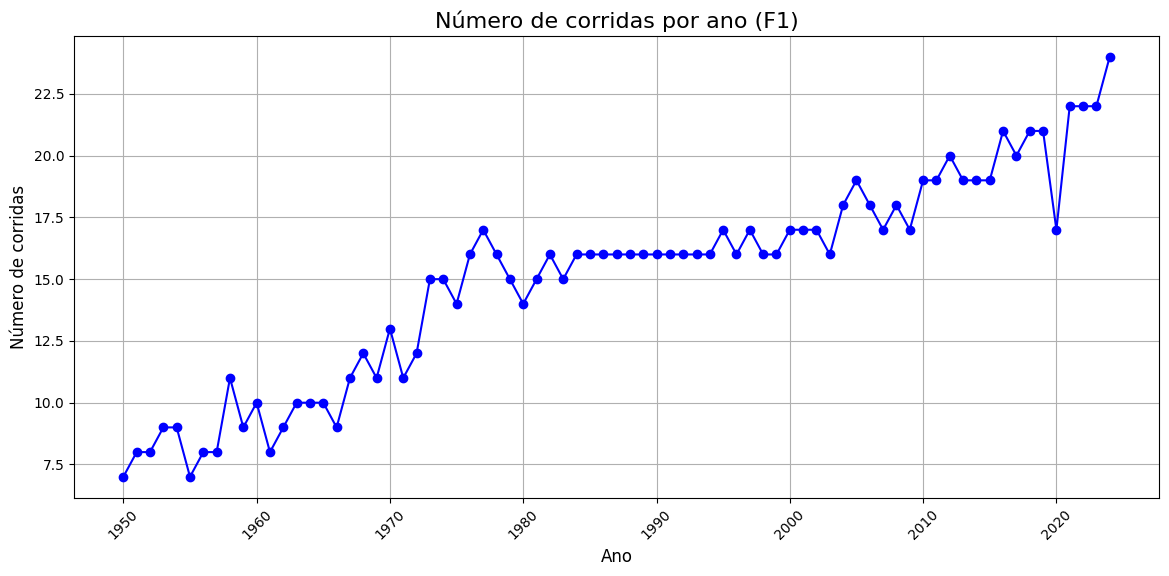

In [11]:
races_per_year = races.groupby('year')['raceId'].count()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(races_per_year.index, races_per_year.values, marker='o', color='blue')
plt.title("Número de corridas por ano (F1)", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de corridas", fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Qual paises mais receberam Grand Prix?

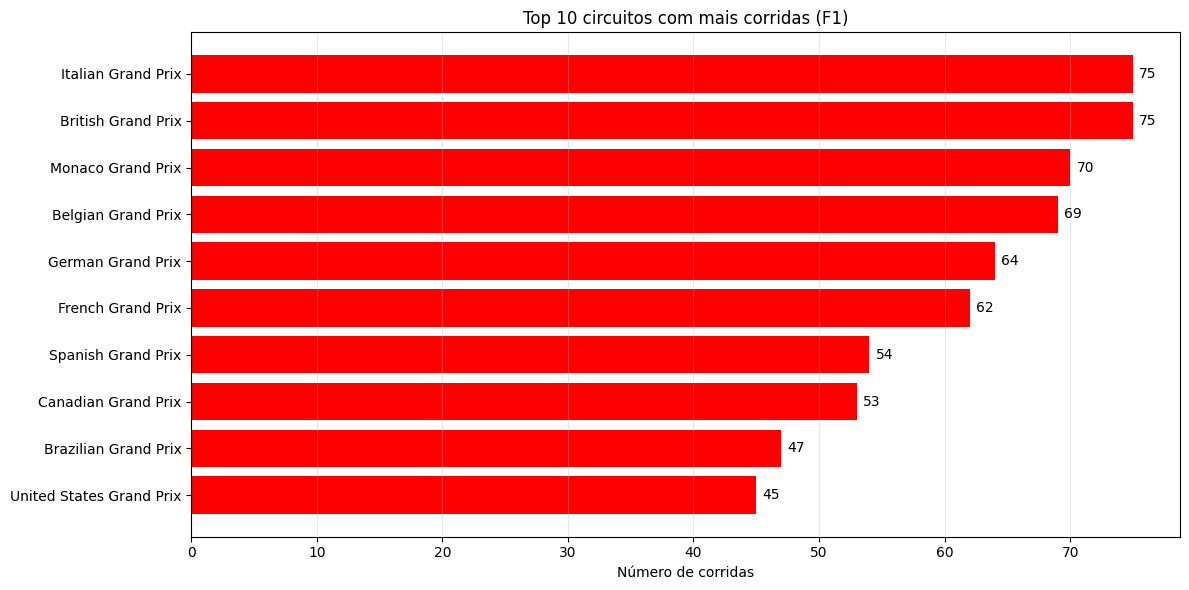

In [12]:
import matplotlib.pyplot as plt

races_count_by_country = races['name'].value_counts()
top_10_circuits = races_count_by_country.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_10_circuits.index[::-1], top_10_circuits.values[::-1], color='red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, str(int(width)), va='center')

plt.xlabel("Número de corridas")
plt.title("Top 10 circuitos com mais corridas (F1)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Quantos circuitos já receberam Grand Prix?

In [13]:
num_circuits = len(circuits['name'].unique())
print(f"Número de circuitos: {num_circuits}")

Número de circuitos: 77


# Quantos pilotos já passaram na F1?

In [14]:
num_drivers = len(drivers['driverId'].unique())
print(f"Número de pilotos: {num_drivers}")

Número de pilotos: 861


# Quais pilotos mais participaram de corridas?

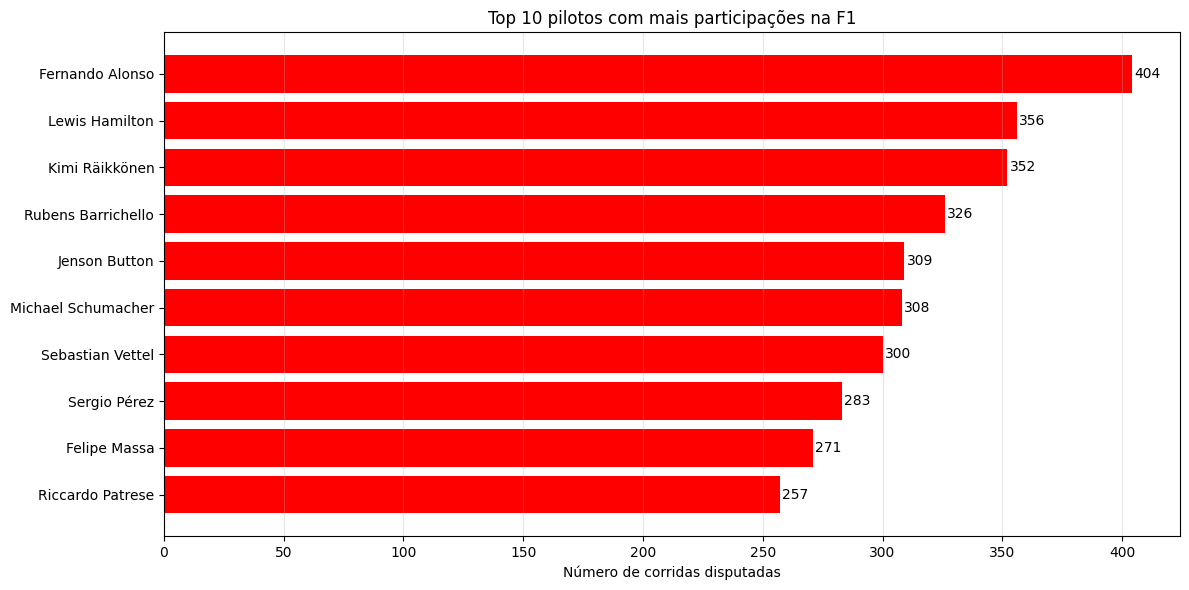

In [15]:
import matplotlib.pyplot as plt

participation_counts = results['driver_name'].value_counts()

top_10 = participation_counts.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_10.index[::-1], top_10.values[::-1], color='red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, str(int(width)), va='center')

plt.xlabel("Número de corridas disputadas")
plt.title("Top 10 pilotos com mais participações na F1")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Quais pilotos mais venceram corridas?

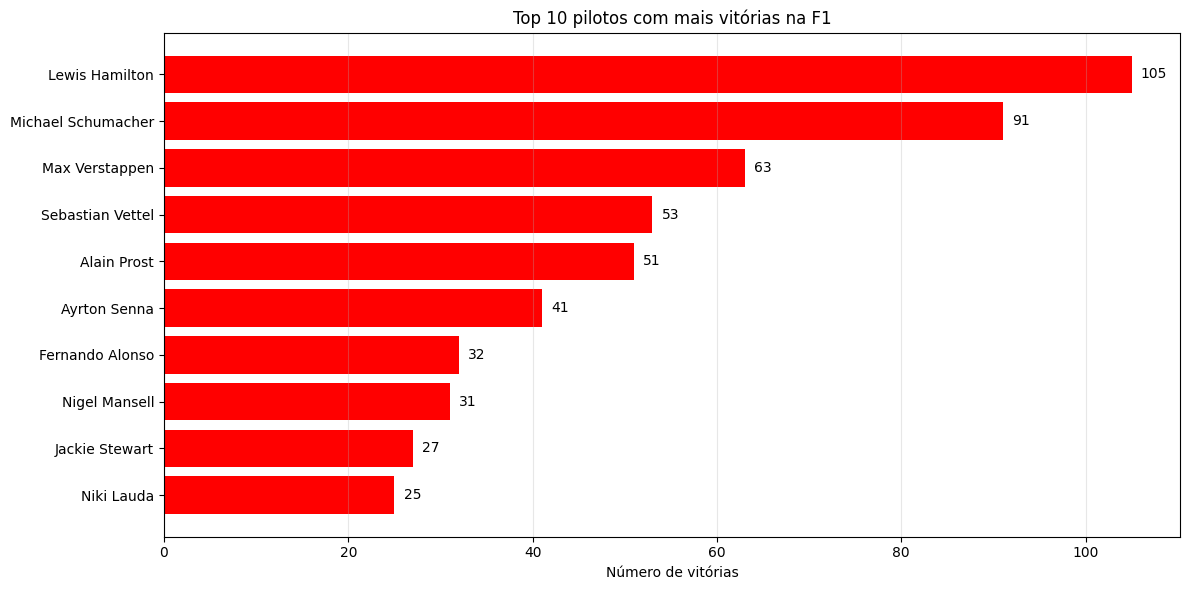

In [16]:
import matplotlib.pyplot as plt

results['position'] = pd.to_numeric(results['position'], errors='coerce')

winners = results[results['position'] == 1]
victory_counts = winners['driver_name'].value_counts()
top_10 = victory_counts.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_10.index[::-1], top_10.values[::-1], color='red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, str(int(width)), va='center')

plt.xlabel("Número de vitórias")
plt.title("Top 10 pilotos com mais vitórias na F1")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Quais equipes mais venceram corridas?

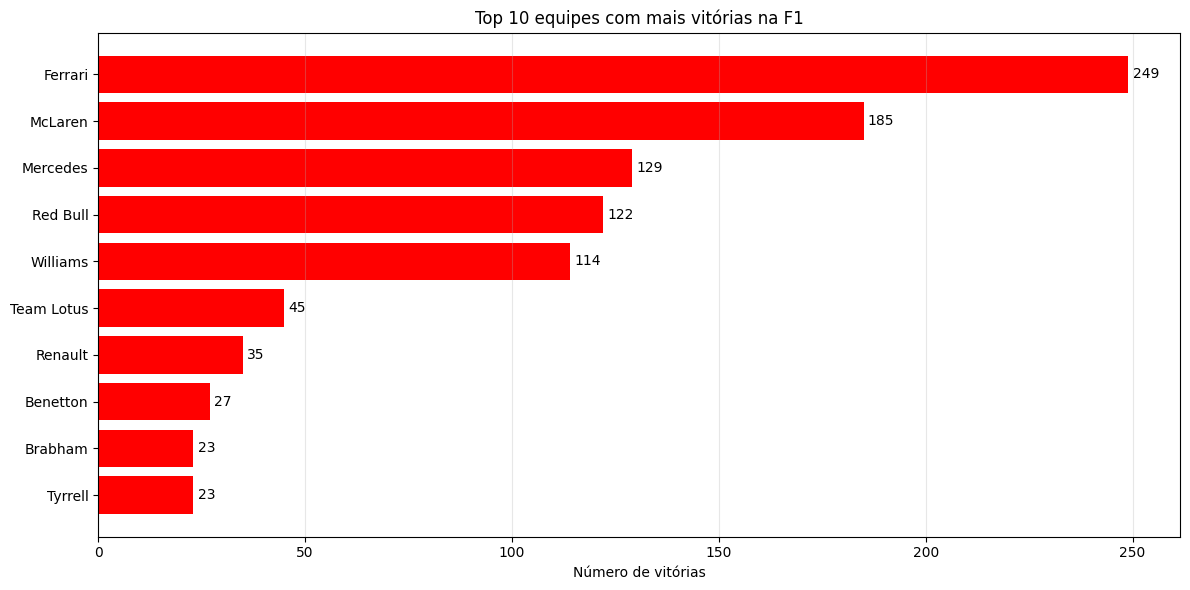

In [25]:
import matplotlib.pyplot as plt

results['position'] = pd.to_numeric(results['position'], errors='coerce')

winners = results[results['position'] == 1]
victory_counts = winners['constructor_name'].value_counts()
top_10 = victory_counts.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_10.index[::-1], top_10.values[::-1], color='red')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, str(int(width)), va='center')

plt.xlabel("Número de vitórias")
plt.title("Top 10 equipes com mais vitórias na F1")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Qual foi a maior velocidade média registrada em uma volta?

In [26]:
results['fastestLapSpeed'] = pd.to_numeric(results['fastestLapSpeed'], errors='coerce')

max_speed = results['fastestLapSpeed'].max()
max_speed_info = results[results['fastestLapSpeed'] == max_speed][['driver_name', 'raceId', 'fastestLapSpeed']]

driver_name = max_speed_info.iloc[0]['driver_name']
race_id = max_speed_info.iloc[0]['raceId']

print(f"Maior velocidade média de volta registrada: {driver_name} — {max_speed} km/h (raceId {race_id})")

Maior velocidade média de volta registrada: Rubens Barrichello — 257.32 km/h (raceId 104)
